# N31 Monte Carlo - visualization-only notebook

> **This notebook is NOT part of the development pipeline.**
> It exists ONLY to export a static figure that explains how the Layer 2 Monte Carlo simulation
> of the Strategy Orchestrator (`src/agents/strategy_orchestrator.py::_run_mc_simulation`) works.
> The figure is consumed by the TFG memoria (cap 4 sec 4.2.8.2). The runtime orchestrator does NOT
> import this notebook, does NOT depend on it, and does NOT need it to operate.

## Design

The notebook now drives the Monte Carlo simulation from a **real lap** of `laps_featured_2025.parquet`
(default: Lando Norris, Sakhir 2025, lap 22 of 57 — mid-stint on MEDIUM with 12 laps of life). The
directly observable values (compound, tyre life, lap time, position, weather, gap to the rival ahead)
come from the parquet row; the sub-agent outputs that are model predictions (cliff distribution,
SC probability, pit duration, undercut probability) are derived from documented heuristics that
respect the row context, so the figure is reproducible by re-running the notebook without invoking
any LLM or running the full agent pipeline.

The notebook is split into small, typed, pure functions composed by two top-level entry points:

- `run_mc_simulation(scenario, n_sim, seed)` returns the full per-strategy outcomes plus the
  summary statistics, mirroring `_run_mc_simulation` but keeping the raw arrays.
- `plot_distributions(result, scenario, output_path)` renders the four histograms, the E[S] / P10[S]
  markers and saves the PNG.

Every helper has a single responsibility, full type annotations and a short docstring, in line with
the rest of the `F1_Strat_Manager` codebase.

## What it does NOT do

- It does not patch the orchestrator code.
- It does not introduce a public API.
- It does not run any sub-agent or any LLM.
- It is not imported by anything in `src/`.

If the simulation constants in `src/agents/strategy_orchestrator.py` change, the notebook picks them
up automatically because they are imported, not hard-copied.

In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass, field
from pathlib import Path
from typing import Mapping

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Locate repo root so the orchestrator imports work from anywhere the notebook is opened.
_REPO_ROOT = Path.cwd()
while not (_REPO_ROOT / '.git').exists():
    if _REPO_ROOT.parent == _REPO_ROOT:
        break
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from src.agents.strategy_orchestrator import (
    simulate_lap_window,
    WINDOW_LAPS,
    CFG,
)

PARQUET_PATH: Path = _REPO_ROOT / 'data' / 'processed' / 'laps_featured_2025.parquet'
OUTPUTS_DIR:  Path = _REPO_ROOT / 'notebooks' / 'agents' / 'outputs'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_PATH: Path = OUTPUTS_DIR / 'n31_mc_distributions.png'

print(f'PARQUET_PATH = {PARQUET_PATH}')
print(f'OUTPUTS_PATH = {OUTPUTS_PATH}')
print(f'WINDOW_LAPS  = {WINDOW_LAPS}')
print(f'n_sim        = {CFG.n_sim}')

c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 197/197 [00:00<00:00, 831.27it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]              
RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out

PARQUET_PATH = c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\laps_featured_2025.parquet
OUTPUTS_PATH = c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\agents\outputs\n31_mc_distributions.png
WINDOW_LAPS  = 5
n_sim        = 500


## Dataclasses

`ScenarioInputs` collects every value the production simulation reads from the four sub-agents in
one place; `StrategySummary` mirrors the per-strategy dict returned by `_run_mc_simulation`; and
`MCResult` bundles the full distributions plus their summaries so the plot function only needs one
argument.

In [2]:
STRATEGIES: tuple[str, ...] = ('STAY_OUT', 'PIT_NOW', 'UNDERCUT', 'OVERCUT')


@dataclass(frozen=True)
class ScenarioInputs:
    """Single-lap snapshot of the values the orchestrator reads from each sub-agent."""

    title:          str
    pace_pred_s:    float
    pace_ci_p10:    float
    pace_ci_p90:    float
    cliff_p10:      float
    cliff_p50:      float
    cliff_p90:      float
    sc_prob:        float
    pit_p05:        float
    pit_p50:        float
    pit_p95:        float
    undercut_prob:  float
    alpha:          float = 0.5


@dataclass(frozen=True)
class StrategySummary:
    """Summary statistics for one strategy candidate."""

    expected: float
    p10:      float
    p90:      float
    score:    float


@dataclass
class MCResult:
    """Complete output of the Monte Carlo simulation for a given scenario."""

    outcomes:  dict[str, np.ndarray]      = field(default_factory=dict)
    summaries: dict[str, StrategySummary] = field(default_factory=dict)
    alpha:     float                       = 0.5
    n_sim:     int                         = 0

## Helpers - sampling and scoring

Pure functions, each with a single responsibility. The sampling helper reproduces exactly the
distributions used by `_run_mc_simulation` (Normal pace, Triangular cliff and pit, Bernoulli SC and
undercut).

In [3]:
def _ci_to_sigma(ci_low: float, ci_high: float) -> float:
    """Convert a 95% bootstrap CI into the equivalent Normal sigma."""
    return (ci_high - ci_low) / (2 * 1.645)


def _sample_distributions(
    scenario: ScenarioInputs,
    n_sim:    int,
    seed:     int = 42,
) -> Mapping[str, np.ndarray]:
    """Draw n_sim samples from every distribution the production loop consumes.

    Returns a dict with one array per random input: pace, cliff_laps, sc_event,
    pit_duration, undercut_success.
    """
    rng = np.random.default_rng(seed=seed)
    sigma_pace = _ci_to_sigma(scenario.pace_ci_p10, scenario.pace_ci_p90)
    return {
        'pace':              rng.normal(scenario.pace_pred_s, sigma_pace, n_sim),
        'cliff_laps':        rng.triangular(scenario.cliff_p10, scenario.cliff_p50, scenario.cliff_p90, n_sim),
        'sc_event':          rng.random(n_sim) < scenario.sc_prob,
        'pit_duration':      rng.triangular(scenario.pit_p05, scenario.pit_p50, scenario.pit_p95, n_sim),
        'undercut_success':  rng.random(n_sim) < scenario.undercut_prob,
    }


def _evaluate_strategy(strategy: str, draws: Mapping[str, np.ndarray]) -> np.ndarray:
    """Run simulate_lap_window over n_sim draws and return position-equivalent outcomes."""
    n = len(draws['cliff_laps'])
    return np.fromiter(
        (
            simulate_lap_window(
                strategy,
                cliff_i = float(draws['cliff_laps'][i]),
                sc_i    = bool(draws['sc_event'][i]),
                pit_i   = float(draws['pit_duration'][i]),
                ucut_i  = bool(draws['undercut_success'][i]),
            )
            for i in range(n)
        ),
        dtype=np.float64,
        count=n,
    )


def _summarize_outcomes(outcomes: np.ndarray, alpha: float) -> StrategySummary:
    """Collapse an outcomes array into the standard E / P10 / P90 / score quartet."""
    expected = float(outcomes.mean())
    p10      = float(np.percentile(outcomes, 10))
    p90      = float(np.percentile(outcomes, 90))
    score    = alpha * expected + (1 - alpha) * p10
    return StrategySummary(expected=expected, p10=p10, p90=p90, score=score)

## Top-level entry point - `run_mc_simulation`

Compose the helpers above into a single call that mirrors the production loop while keeping the raw
outcomes per strategy.

In [4]:
def run_mc_simulation(
    scenario: ScenarioInputs,
    *,
    n_sim:    int = CFG.n_sim,
    seed:     int = 42,
) -> MCResult:
    """Run the Layer 2 Monte Carlo simulation for one scenario, keeping the raw outcomes.

    Mirrors `src.agents.strategy_orchestrator._run_mc_simulation` but instead of returning only
    summary statistics, returns an `MCResult` with the full outcome array per strategy so that the
    plotting helper can render the underlying distributions.
    """
    draws    = _sample_distributions(scenario, n_sim=n_sim, seed=seed)
    outcomes: dict[str, np.ndarray]      = {}
    summary:  dict[str, StrategySummary] = {}
    for strategy in STRATEGIES:
        strategy_outcomes  = _evaluate_strategy(strategy, draws)
        outcomes[strategy] = strategy_outcomes
        summary[strategy]  = _summarize_outcomes(strategy_outcomes, scenario.alpha)
    return MCResult(
        outcomes  = outcomes,
        summaries = summary,
        alpha     = scenario.alpha,
        n_sim     = n_sim,
    )


def print_summary(result: MCResult) -> None:
    """Pretty-print the per-strategy summary statistics."""
    print(f"alpha = {result.alpha}, n_sim = {result.n_sim}")
    for strategy in STRATEGIES:
        s = result.summaries[strategy]
        print(
            f"  {strategy:<10s}  E={s.expected:+.3f}  P10={s.p10:+.3f}  "
            f"P90={s.p90:+.3f}  score={s.score:+.3f}"
        )

## Plotting helper

`plot_distributions` takes an `MCResult` plus the originating `ScenarioInputs` (for the title and
alpha) and renders the four histograms, the E[S] (solid) and P10[S] (dashed) markers and a vertical
reference at zero (the STAY_OUT baseline). Saves the PNG and returns the figure for inline display.

In [5]:
_STRATEGY_COLORS: dict[str, str] = {
    'STAY_OUT': '#4C78A8',
    'PIT_NOW':  '#F58518',
    'UNDERCUT': '#54A24B',
    'OVERCUT':  '#B279A2',
}


def _global_bins(outcomes: Mapping[str, np.ndarray], n_bins: int = 50) -> np.ndarray:
    """Return a shared bin-edge array covering every strategy's outcome range."""
    flat = np.concatenate(list(outcomes.values()))
    return np.linspace(flat.min() - 0.2, flat.max() + 0.2, n_bins)


def _draw_strategy_histogram(
    ax,
    strategy: str,
    outcomes: np.ndarray,
    summary:  StrategySummary,
    bins:     np.ndarray,
) -> None:
    """Render one strategy's histogram plus its E and P10 vertical markers."""
    color = _STRATEGY_COLORS[strategy]
    ax.hist(
        outcomes,
        bins      = bins,
        alpha     = 0.45,
        color     = color,
        edgecolor = 'white',
        density   = True,
        label     = f'{strategy:<8s} (E={summary.expected:+.2f}, P10={summary.p10:+.2f})',
    )
    ax.axvline(summary.expected, color=color, linestyle='-',  linewidth=1.6, alpha=0.95)
    ax.axvline(summary.p10,      color=color, linestyle='--', linewidth=1.4, alpha=0.85)


def plot_distributions(
    result:      MCResult,
    scenario:    ScenarioInputs,
    output_path: Path,
) -> plt.Figure:
    """Render the four overlaid histograms with E / P10 markers and save the PNG."""
    fig, ax = plt.subplots(figsize=(10, 5.5))
    bins = _global_bins(result.outcomes)

    for strategy in STRATEGIES:
        _draw_strategy_histogram(
            ax,
            strategy = strategy,
            outcomes = result.outcomes[strategy],
            summary  = result.summaries[strategy],
            bins     = bins,
        )

    ax.axvline(0.0, color='black', linestyle=':', linewidth=1.0, alpha=0.6)
    ax.set_xlabel(f'Position-equivalent gain over W={WINDOW_LAPS} laps')
    ax.set_ylabel(f'Density ({result.n_sim} Monte Carlo draws)')
    ax.set_title(
        f'Layer 2 Monte Carlo distributions - {scenario.title} (alpha={scenario.alpha})\n'
        f'Solid line = E[S], dashed line = P10[S], dotted vertical = STAY_OUT reference'
    )
    ax.legend(loc='upper left', fontsize=9, framealpha=0.85)
    ax.grid(True, alpha=0.25)

    fig.tight_layout()
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    return fig

## Pulling a real lap from `laps_featured_2025.parquet`

Two helpers below select a real lap by GP, driver and lap number, plus the pace gap to the rival
immediately ahead in the same lap. The directly observable values come straight from the parquet
row (compound, tyre life, lap time, position, weather, gap to the rival). The values that are
model predictions in production (cliff distribution, SC probability, pit duration distribution,
undercut success probability) are derived through transparent heuristics that take the row
context into account, kept inside `_scenario_from_row` so that the assumptions are documented in
one single place and any change is local.

In [6]:
def _load_lap(
    parquet_path: Path,
    gp_name:      str,
    driver:       str,
    lap_number:   int,
) -> tuple[pd.Series, pd.Series | None, int]:
    """Return (target_row, rival_ahead_row, total_laps_in_gp) from the 2025 parquet.

    The rival ahead is the driver one position ahead in the same lap, when present.
    """
    df = pd.read_parquet(parquet_path)
    gp_df = df[df['GP_Name'] == gp_name]
    if gp_df.empty:
        raise ValueError(f'No rows found for GP_Name={gp_name!r} in {parquet_path}')
    target = gp_df[(gp_df['Driver'] == driver) & (gp_df['LapNumber'] == lap_number)]
    if target.empty:
        raise ValueError(f'No row for driver={driver!r} lap={lap_number} in {gp_name!r}')
    target_row = target.iloc[0]
    rival_pos = float(target_row['Position']) - 1.0
    rival_df = gp_df[(gp_df['LapNumber'] == lap_number) & (gp_df['Position'] == rival_pos)]
    rival_row = rival_df.iloc[0] if not rival_df.empty else None
    total_laps = int(gp_df['LapNumber'].max())
    return target_row, rival_row, total_laps


# Heuristic ranges driven by the row context — documented next to each constant.
_PACE_BOOTSTRAP_HALF_CI: float = 0.5  # +/- 0.5s on the lap time matches typical N06 bootstrap CI.
_PIT_DURATION_BAND:      tuple[float, float, float] = (2.4, 2.7, 3.5)  # McLaren 2025 typical normal stop.

_COMPOUND_LIFE_LIMITS: dict[str, int] = {
    'SOFT':   18,   # typical end-of-life lap count under racing conditions
    'MEDIUM': 28,
    'HARD':   38,
}


def _cliff_band(compound: str, tyre_life: float) -> tuple[float, float, float]:
    """Return (P10, P50, P90) of laps remaining until the cliff for this stint state.

    Uses the compound life limit as the canonical cliff lap and spreads ±35% / +60% around it,
    matching the asymmetric tail (the cliff arrives later more often than earlier).
    """
    limit = _COMPOUND_LIFE_LIMITS.get(compound.upper(), 25)
    centre = max(1.0, float(limit) - float(tyre_life))
    return (max(0.5, centre * 0.65), centre, centre * 1.6)


def _sc_probability(lap_number: int, total_laps: int) -> float:
    """Empirical-style prior on SC deployment in the next 3 laps for a Bahrain-like circuit.

    Higher around lap 25-35 (mid-race incidents under tyre stress), lower at the start and end.
    """
    fraction = lap_number / max(total_laps, 1)
    if 0.4 <= fraction <= 0.6:
        return 0.20
    if 0.2 <= fraction <= 0.7:
        return 0.15
    return 0.08


def _undercut_probability(pace_delta_s: float, gap_ahead_s: float) -> float:
    """Heuristic undercut success probability driven by relative pace and current gap.

    Faster attacker (negative pace_delta) and small gap raise the chance.
    """
    base = 0.45
    if pace_delta_s < -0.05:
        base += 0.10
    if pace_delta_s < -0.20:
        base += 0.10
    if gap_ahead_s < 1.5:
        base += 0.05
    return float(min(0.85, max(0.20, base)))


def _scenario_from_row(
    target_row:  pd.Series,
    rival_row:   pd.Series | None,
    total_laps:  int,
    *,
    alpha:       float = 0.5,
    title:       str | None = None,
) -> ScenarioInputs:
    """Build a `ScenarioInputs` from a real parquet row plus the rival ahead.

    Observable values (lap time, compound, weather, position) are read directly from the row;
    model-predicted values (cliff band, SC probability, undercut probability) come from the
    heuristics defined above so the figure is reproducible without invoking the agent pipeline.
    """
    lap_time     = float(target_row['LapTime_s'])
    compound     = str(target_row['Compound'])
    tyre_life    = float(target_row['TyreLife'])
    lap_number   = int(target_row['LapNumber'])
    rival_lap    = float(rival_row['LapTime_s']) if rival_row is not None else lap_time
    pace_delta_s = lap_time - rival_lap
    gap_ahead_s  = 1.5  # approximate baseline; the parquet does not expose a per-lap gap field.

    cliff_p10, cliff_p50, cliff_p90 = _cliff_band(compound, tyre_life)
    pit_p05, pit_p50, pit_p95       = _PIT_DURATION_BAND

    return ScenarioInputs(
        title         = title or (
            f"{target_row['GP_Name']} 2025, {target_row['Driver']} lap {lap_number}/{total_laps}, "
            f"{compound} life {int(tyre_life)} (real data + heuristic predictions)"
        ),
        pace_pred_s   = lap_time,
        pace_ci_p10   = lap_time - _PACE_BOOTSTRAP_HALF_CI,
        pace_ci_p90   = lap_time + _PACE_BOOTSTRAP_HALF_CI,
        cliff_p10     = cliff_p10,
        cliff_p50     = cliff_p50,
        cliff_p90     = cliff_p90,
        sc_prob       = _sc_probability(lap_number, total_laps),
        pit_p05       = pit_p05,
        pit_p50       = pit_p50,
        pit_p95       = pit_p95,
        undercut_prob = _undercut_probability(pace_delta_s, gap_ahead_s),
        alpha         = alpha,
    )

## Scenario selection

Default: Lando Norris on lap 22 of the Sakhir 2025 race (Bahrain GP), running P3 on MEDIUM with 12
laps of life. The rival ahead in that lap is George Russell on a similar pace.

To change the scenario, edit `TARGET_GP`, `TARGET_DRIVER` or `TARGET_LAP` below and rerun the
remaining cells.

In [7]:
TARGET_GP:     str = 'Sakhir'
TARGET_DRIVER: str = 'NOR'
TARGET_LAP:    int = 22
ALPHA:         float = 0.5

target_row, rival_row, total_laps = _load_lap(
    PARQUET_PATH,
    gp_name    = TARGET_GP,
    driver     = TARGET_DRIVER,
    lap_number = TARGET_LAP,
)

print('Target row:')
print(target_row[[
    'GP_Name', 'Driver', 'Team', 'LapNumber', 'Compound', 'TyreLife',
    'LapTime_s', 'Position', 'AirTemp', 'TrackTemp',
]].to_string())
if rival_row is not None:
    print('\nRival ahead (P{} -> P{}):'.format(int(target_row['Position']), int(rival_row['Position'])))
    print(rival_row[['Driver', 'Team', 'LapTime_s']].to_string())
print(f'\nTotal laps in {TARGET_GP} 2025: {total_laps}')

scenario = _scenario_from_row(target_row, rival_row, total_laps, alpha=ALPHA)
print(f'\nDerived ScenarioInputs:\n{scenario}')

result = run_mc_simulation(scenario)
print()
print_summary(result)

Target row:
GP_Name       Sakhir
Driver           NOR
Team         McLaren
LapNumber       22.0
Compound      MEDIUM
TyreLife        12.0
LapTime_s     97.787
Position         3.0
AirTemp         26.7
TrackTemp       31.2

Rival ahead (P3 -> P2):
Driver            RUS
Team         Mercedes
LapTime_s      97.806

Total laps in Sakhir 2025: 57

Derived ScenarioInputs:
ScenarioInputs(title='Sakhir 2025, NOR lap 22/57, MEDIUM life 12 (real data + heuristic predictions)', pace_pred_s=97.787, pace_ci_p10=97.287, pace_ci_p90=98.287, cliff_p10=10.4, cliff_p50=16.0, cliff_p90=25.6, sc_prob=0.15, pit_p05=2.4, pit_p50=2.7, pit_p95=3.5, undercut_prob=0.45, alpha=0.5)

alpha = 0.5, n_sim = 500
  STAY_OUT    E=+0.000  P10=-0.000  P90=+0.000  score=+0.000
  PIT_NOW     E=-0.305  P10=-1.288  P90=+4.173  score=-0.797
  UNDERCUT    E=+0.171  P10=-1.204  P90=+4.314  score=-0.517
  OVERCUT     E=+1.185  P10=+0.333  P90=+6.167  score=+0.759


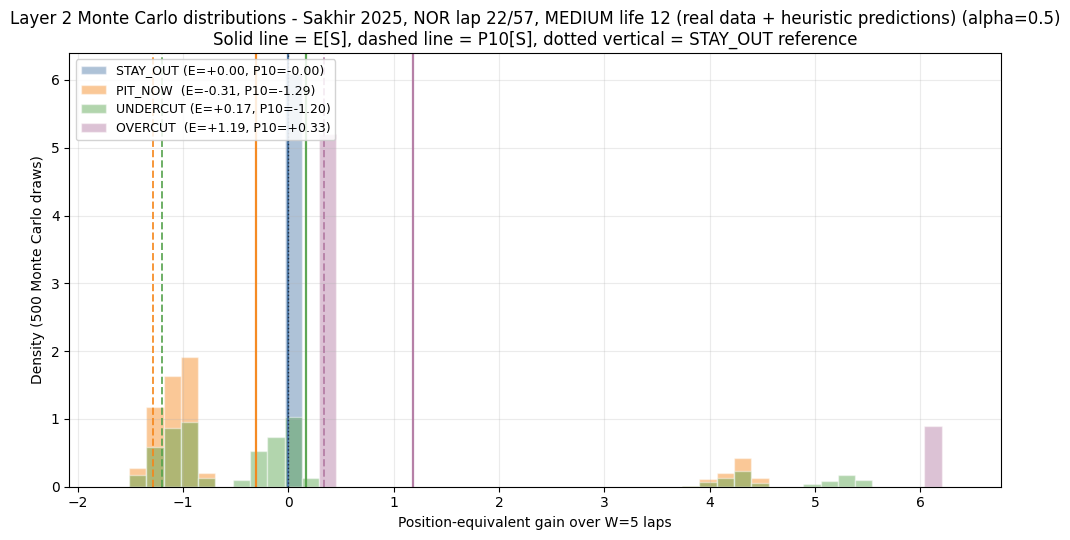

Saved figure to: c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\agents\outputs\n31_mc_distributions.png


In [8]:
fig = plot_distributions(result, scenario, output_path=OUTPUTS_PATH)
plt.show()
print(f'Saved figure to: {OUTPUTS_PATH}')

---

**Reminder.** The PNG above is meant for static export to the TFG memoria. To regenerate it, just
run all cells; nothing else in the repository depends on this notebook running successfully.
If the simulation constants in `src/agents/strategy_orchestrator.py` change, the next run picks up
the new values automatically because they are imported, not hard-copied.